In [13]:
# ===== ME0SegReco Setup =====
import sys
import site

user_site = site.USER_SITE
me0_src = '/eos/home-i01/k/kkeshav/SWAN_projects/me0_v2/ME0SegReco/src'

for path in [user_site, me0_src]:
    if path not in sys.path:
        sys.path.insert(0, path)

from me0.data.datasets.GNNDataset import GNNDataset
from me0.modules.gnn.model import HitGNN
print("✓ ME0SegReco loaded")

✓ ME0SegReco loaded


In [14]:
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from me0.data.datasets.image import ME0DigiImageDataset
from me0.modules.cnn.model import ME0SegCNN3d
from me0.losses import ME0BCELoss

torch.set_num_threads(5)

In [15]:
model = ME0SegCNN3d(
    in_channels = 3, # (hitmap, cls, bx)
    out_channels = 1,
    hidden_channels_list = [2, 4, 2],
    kernel_size = (3, 3, 7),
    activation = "GELU",
).to_tensor_dict_module()

model

TensorDictModule(
    module=ME0SegCNN3d(
      (activation): GELU(approximate='none')
      (residual_block_list): ModuleList(
        (0): ResidualBlock(
          (convbn1): ConvBn(
            (conv): Conv3d(3, 2, kernel_size=(3, 3, 7), stride=(1, 1, 1), padding=same, bias=False)
            (bn): BatchNorm3d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (activation): GELU(approximate='none')
          (convbn2): ConvBn(
            (conv): Conv3d(2, 2, kernel_size=(3, 3, 7), stride=(1, 1, 1), padding=same, bias=False)
            (bn): BatchNorm3d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (res): Conv3d(3, 2, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
        )
        (1): ResidualBlock(
          (convbn1): ConvBn(
            (conv): Conv3d(2, 4, kernel_size=(3, 3, 7), stride=(1, 1, 1), padding=same, bias=False)
            (bn): BatchNorm3d(4, eps=1e-05, momentum=0.1, affine=True

In [16]:
dataset = ME0DigiImageDataset(
    file='../data/step4_0.h5',
    features={
        'cls': {'min': 1, 'max': 384},
        'bx': {'min': -3, 'max': 3},
    },
    get_central_bx=True,
)

processing 35430 events: 100%|██████████| 1/1 [00:25<00:00, 25.78s/it]


In [17]:
n_train = 10000
n_val = 10000

train_loader = DataLoader(dataset[:n_train], collate_fn=dataset.collate, shuffle=True, drop_last=True, batch_size=64)
val_loader = DataLoader(dataset[n_train:n_train+n_val], collate_fn=dataset.collate, shuffle=False, drop_last=True, batch_size=128)

In [18]:
batch = next(iter(train_loader))
batch

TensorDict(
    fields={
        data_mask: Tensor(shape=torch.Size([64, 8, 6, 384]), device=cpu, dtype=torch.bool, is_shared=False),
        eta: Tensor(shape=torch.Size([64, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        input: Tensor(shape=torch.Size([64, 3, 8, 6, 384]), device=cpu, dtype=torch.float32, is_shared=False),
        phi: Tensor(shape=torch.Size([64, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        pt: Tensor(shape=torch.Size([64, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        target: Tensor(shape=torch.Size([64, 8, 6, 384]), device=cpu, dtype=torch.int32, is_shared=False)},
    batch_size=torch.Size([64]),
    device=None,
    is_shared=False)

In [19]:
out = model(batch)
out

TensorDict(
    fields={
        data_mask: Tensor(shape=torch.Size([64, 8, 6, 384]), device=cpu, dtype=torch.bool, is_shared=False),
        eta: Tensor(shape=torch.Size([64, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        input: Tensor(shape=torch.Size([64, 3, 8, 6, 384]), device=cpu, dtype=torch.float32, is_shared=False),
        logits: Tensor(shape=torch.Size([64, 8, 6, 384]), device=cpu, dtype=torch.float32, is_shared=False),
        phi: Tensor(shape=torch.Size([64, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        preds: Tensor(shape=torch.Size([64, 8, 6, 384]), device=cpu, dtype=torch.float32, is_shared=False),
        pt: Tensor(shape=torch.Size([64, 1]), device=cpu, dtype=torch.float32, is_shared=False),
        target: Tensor(shape=torch.Size([64, 8, 6, 384]), device=cpu, dtype=torch.int32, is_shared=False)},
    batch_size=torch.Size([64]),
    device=None,
    is_shared=False)

In [20]:
pad_mask = batch['data_mask'].logical_not()


(out['preds'] == torch.sigmoid(out['logits']).masked_fill(pad_mask, 0.)).all(dim=(1,2,3))

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])

In [21]:
num_pos = 0
num_neg = 0
for batch in tqdm(train_loader):
    neg, pos = torch.bincount(batch['target'][batch['data_mask']])
    num_pos += pos
    num_neg += neg

pos_weight = num_neg / num_pos
print(f"{pos_weight=}")

100%|██████████| 156/156 [00:06<00:00, 22.83it/s]

pos_weight=tensor(73.5827)


In [22]:
loss_fn = ME0BCELoss(pos_weight=pos_weight).to_tensor_dict_module()

loss = loss_fn(out)['loss']
loss.backward()
print(f"{loss=}")

loss=tensor(1.7916, grad_fn=<DivBackward0>)


In [24]:
# quick and dirty function to count the parameter of model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())
total_params = count_parameters(model)
print(f"Total parameter: {total_params}")

Total parameter: 3147


In [ ]:
optim = torch.optim.AdamW(model.parameters(), lr=0.003)

out_df = pd.DataFrame(columns=['epoch', 'step', 'train_loss', 'val_loss'])

num_epoch = 5
step = 0

for epoch in range(num_epoch+1):
    # validation
    if epoch == 0:
        with torch.inference_mode():
            loss = 0
            for batch in tqdm(val_loader):
                out = model(batch)
                loss += loss_fn(out)['loss'].item()
            out_df.loc[len(out_df)] = [epoch, step, None, loss/len(val_loader)]
        print(f"""
        Epoch {epoch}/{num_epoch}
            val_loss: {out_df[(out_df['epoch'] == epoch)]['val_loss'].dropna().mean()}
        """)            
        continue
    for batch in tqdm(train_loader):
        optim.zero_grad()
        out = model(batch)
        loss = loss_fn(out)['loss']
        loss.backward()
        optim.step()
        out_df.loc[len(out_df)] = [epoch, step, loss.item(), None]
        step += 1
        
    with torch.inference_mode():
        loss = 0
        for batch in tqdm(val_loader):
            out = model(batch)
            loss += loss_fn(out)['loss'].item()
        out_df.loc[len(out_df)] = [epoch, step, None, loss/len(val_loader)]
    
    print(f"""
    Epoch {epoch}/{num_epoch}
        train_loss: {out_df[(out_df['epoch'] == epoch)]['train_loss'].dropna().mean()}
        val_loss: {out_df[(out_df['epoch'] == epoch)]['val_loss'].dropna().mean()}
    """)    

100%|██████████| 78/78 [06:31<00:00,  5.02s/it]



        Epoch 0/5
            val_loss: 1.6351117934936132
        


 94%|█████████▍| 147/156 [22:35<01:22,  9.13s/it]

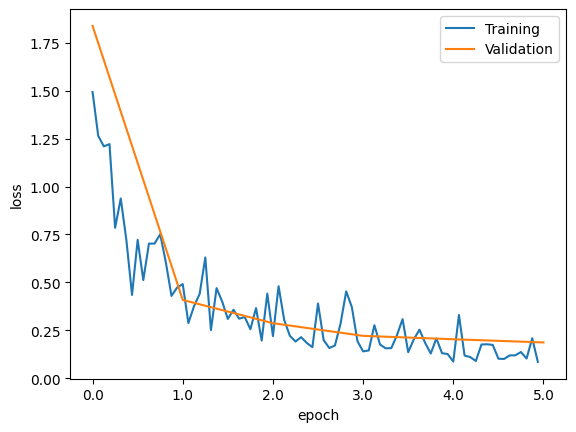

In [15]:
plt.plot(out_df[out_df['train_loss'].notna()]['step'], out_df['train_loss'].dropna(), label='Training')
plt.plot(out_df[out_df['val_loss'].notna()]['step'], out_df['val_loss'].dropna(), label='Validation')
plt.xticks(ticks=out_df[out_df['val_loss'].notna()]['step'], labels=out_df[out_df['val_loss'].notna()]['epoch'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

Computing ROC:   0%|          | 0/2 [00:00<?, ?it/s]OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the librar

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

...

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

Computing ROC: 100%|██████████| 2/2 [00:11<00:00,  5.65s/it]


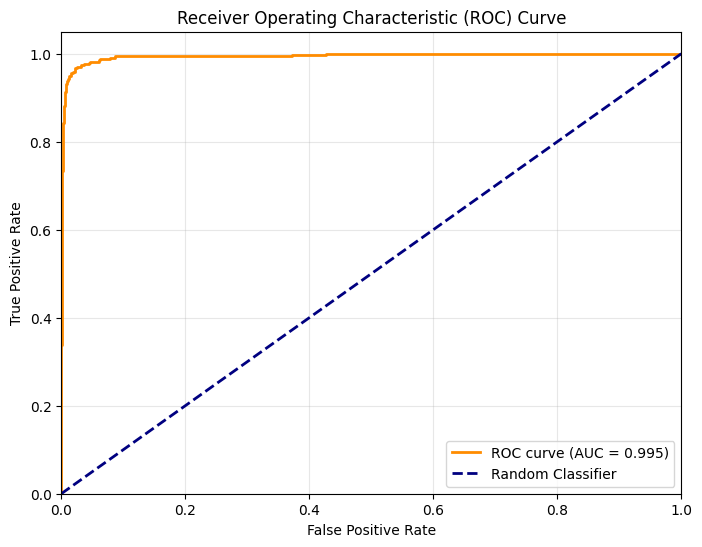

AUC Score: 0.9945


In [23]:
# Cell: ROC Curve Generation (Fixed)
from sklearn.metrics import roc_curve, auc
import numpy as np

# Collect predictions and targets
all_probs = []
all_targets = []

model.eval()
with torch.inference_mode():
    for batch in tqdm(val_loader, desc='Computing ROC'):
        out = model(batch)
        
        # Get probabilities from logits
        probs = torch.sigmoid(out['logits']).squeeze(1)  # Remove channel dim
        targets = batch['target']
        mask = batch['data_mask']  # Only evaluate on valid data
        
        # Flatten and apply mask - use .cpu() not .cuda()
        probs_masked = probs[mask].cpu().numpy()
        targets_masked = targets[mask].cpu().numpy()
        
        all_probs.append(probs_masked)
        all_targets.append(targets_masked)

# Concatenate all batches
all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

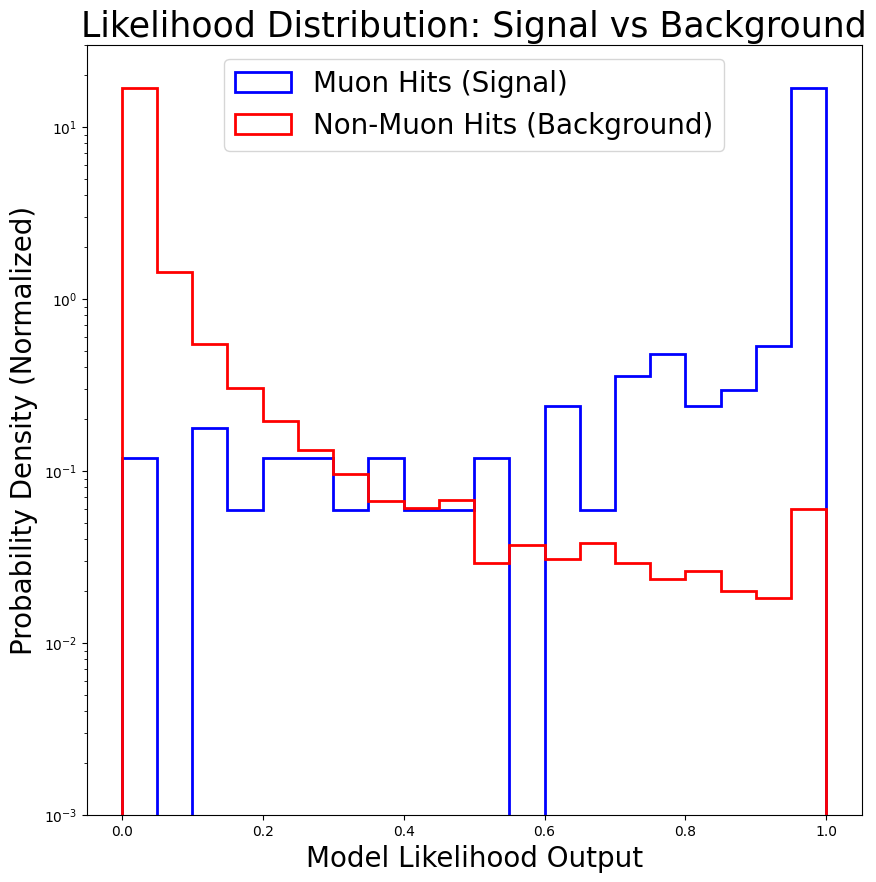

Signal Statistics:
  Count: 337
  Mean: 0.9372
  Median: 0.9993

Background Statistics:
  Count: 22,065
  Mean: 0.0405
  Median: 0.0072


In [30]:
# Cell: Likelihood Distribution - Signal vs Background (Styled for Comparison)
# Separate signal and background
signal_probs = all_probs[all_targets == 1]
background_probs = all_probs[all_targets == 0]

bins = np.linspace(0, 1, 21)
fig, ax = plt.subplots(figsize=(10, 10))

# Muon hits (signal)
plt.hist(
    signal_probs, 
    bins=bins, 
    density=True, 
    label='Muon Hits (Signal)',
    histtype='step',
    color='blue',
    linewidth=2
)

# Non-muon hits (background)
plt.hist(
    background_probs, 
    bins=bins, 
    density=True, 
    label='Non-Muon Hits (Background)',
    histtype='step',
    color='red',
    linewidth=2
)

plt.yscale('log')
plt.legend(fontsize = 20)
plt.xlabel('Model Likelihood Output', fontsize = 20)
plt.ylabel('Probability Density (Normalized)', fontsize = 20)
plt.title('Likelihood Distribution: Signal vs Background', fontsize =25)
plt.ylim(1e-3, 3e1)
plt.show()

# Print summary statistics
print(f"Signal Statistics:")
print(f"  Count: {len(signal_probs):,}")
print(f"  Mean: {signal_probs.mean():.4f}")
print(f"  Median: {np.median(signal_probs):.4f}")

print(f"\nBackground Statistics:")
print(f"  Count: {len(background_probs):,}")
print(f"  Mean: {background_probs.mean():.4f}")
print(f"  Median: {np.median(background_probs):.4f}")

In [19]:
model.eval()


TensorDictModule(
    module=ME0SegCNN3d(
      (activation): GELU(approximate='none')
      (residual_block_list): ModuleList(
        (0): ResidualBlock(
          (convbn1): ConvBn(
            (conv): Conv3d(3, 2, kernel_size=(3, 3, 7), stride=(1, 1, 1), padding=same, bias=False)
            (bn): BatchNorm3d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (activation): GELU(approximate='none')
          (convbn2): ConvBn(
            (conv): Conv3d(2, 2, kernel_size=(3, 3, 7), stride=(1, 1, 1), padding=same, bias=False)
            (bn): BatchNorm3d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (res): Conv3d(3, 2, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
        )
        (1): ResidualBlock(
          (convbn1): ConvBn(
            (conv): Conv3d(2, 4, kernel_size=(3, 3, 7), stride=(1, 1, 1), padding=same, bias=False)
            (bn): BatchNorm3d(4, eps=1e-05, momentum=0.1, affine=True

In [21]:
with torch.inference_mode():
    for batch in tqdm(val_loader, desc= 'Computing ROC'):
        out = model(batch)
        
        #Get probabilities from logits
        probs = torch.sigmoid(out['logits']).squeeze(1)
        targets = batch['target']
        mask = batch['data_mask'] # Only evaluate on valid data
        
        # Flatten and apply mask
        probs_masked = probs[mask].cpu().numpy()
        targets_masked = targets[mask].cpu().numpy
        
        all_probs.append(probs_masked)
        all_targets.append(targets_masked)
        

        
        

Computing ROC:   0%|          | 0/2 [00:00<?, ?it/s]OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the librar

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

...

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

Computing ROC: 100%|██████████| 2/2 [00:11<00:00,  5.60s/it]


In [22]:
# concatenate all batches
all_probs = np.concatenate(all_probs)
all_targets = np.concatenate(all_targets)

ValueError: zero-dimensional arrays cannot be concatenated